In [3]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/CBCT_to_sCT_Project

Mounted at /content/drive
/content/drive/MyDrive/CBCT_to_sCT_Project


In [4]:
!pip install -q SimpleITK pandas matplotlib numpy torch torchvision segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 15.8 MB/s eta 0:00:00


In [5]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [6]:
%%writefile src/model.py
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp


def build_unetplusplus_resnet34(
    in_channels=7,
    out_channels=1,
    encoder_weights="imagenet",
    dropout=0.2
):


    model = smp.UnetPlusPlus(
        encoder_name="resnet34",
        encoder_weights=encoder_weights,
        in_channels=in_channels,
        classes=out_channels,
        activation=None
    )


    model.segmentation_head = nn.Sequential(
        nn.Dropout2d(p=dropout),
        model.segmentation_head
    )

    return model

Writing src/model.py


In [7]:
%%writefile src/losses.py
import torch
import torch.nn as nn


class MaskedL1Loss(nn.Module):


    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, prediction, target, mask=None):
        if mask is None:
            return torch.mean(torch.abs(prediction - target))

        error = torch.abs(prediction - target)
        masked_error = error * mask

        return masked_error.sum() / (mask.sum() + self.eps)

Writing src/losses.py


In [8]:
from src.dataset import SynthRAD2p5DDataset
from src.model import build_unetplusplus_resnet34
from src.losses import MaskedL1Loss

df = pd.read_csv("data/patient_list.csv")

with open("splits/fold_0.json", "r") as f:
    split = json.load(f)

train_dataset = SynthRAD2p5DDataset(
    dataframe=df,
    patient_ids=split["train"],
    input_slices=7,
    image_size=320,
    min_hu=-1000,
    max_hu=1600,
    max_patients=5
)

val_dataset = SynthRAD2p5DDataset(
    dataframe=df,
    patient_ids=split["val"],
    input_slices=7,
    image_size=320,
    min_hu=-1000,
    max_hu=1600,
    max_patients=2
)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

Train samples: 379
Val samples: 152


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0
)

batch = next(iter(train_loader))

print("Input:", batch["input"].shape)
print("Target:", batch["target"].shape)
print("Mask:", batch["mask"].shape)

Input: torch.Size([2, 7, 320, 320])
Target: torch.Size([2, 1, 320, 320])
Mask: torch.Size([2, 1, 320, 320])


In [12]:
model = build_unetplusplus_resnet34(
    in_channels=7,
    out_channels=1,
    encoder_weights="imagenet",
    dropout=0.2
)

model = model.to(device)

criterion = MaskedL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

print("Model created successfully.")

Model created successfully.


In [13]:
batch = next(iter(train_loader))

inputs = batch["input"].to(device)
targets = batch["target"].to(device)
masks = batch["mask"].to(device)

with torch.no_grad():
    outputs = model(inputs)

loss = criterion(outputs, targets, masks)

print("Output shape:", outputs.shape)
print("Loss:", loss.item())

Output shape: torch.Size([2, 1, 320, 320])
Loss: 0.8160880208015442


In [14]:
num_epochs = 3

train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        inputs = batch["input"].to(device)
        targets = batch["target"].to(device)
        masks = batch["mask"].to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 20 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Batch {batch_idx}, Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1} average training loss: {epoch_loss:.4f}")

Epoch 1/3, Batch 0, Loss: 0.8565
Epoch 1/3, Batch 20, Loss: 0.0877
Epoch 1/3, Batch 40, Loss: 0.0773
Epoch 1/3, Batch 60, Loss: 0.1565
Epoch 1/3, Batch 80, Loss: 0.0933
Epoch 1/3, Batch 100, Loss: 0.0979
Epoch 1/3, Batch 120, Loss: 0.1505
Epoch 1/3, Batch 140, Loss: 0.0911
Epoch 1/3, Batch 160, Loss: 0.0542
Epoch 1/3, Batch 180, Loss: 0.0865
Epoch 1 average training loss: 0.1200
Epoch 2/3, Batch 0, Loss: 0.0724
Epoch 2/3, Batch 20, Loss: 0.0576
Epoch 2/3, Batch 40, Loss: 0.1090
Epoch 2/3, Batch 60, Loss: 0.0711
Epoch 2/3, Batch 80, Loss: 0.0792
Epoch 2/3, Batch 100, Loss: 0.0779
Epoch 2/3, Batch 120, Loss: 0.0764
Epoch 2/3, Batch 140, Loss: 0.0750
Epoch 2/3, Batch 160, Loss: 0.1019
Epoch 2/3, Batch 180, Loss: 0.0944
Epoch 2 average training loss: 0.0850
Epoch 3/3, Batch 0, Loss: 0.0743
Epoch 3/3, Batch 20, Loss: 0.0544
Epoch 3/3, Batch 40, Loss: 0.0721
Epoch 3/3, Batch 60, Loss: 0.0616
Epoch 3/3, Batch 80, Loss: 0.0900
Epoch 3/3, Batch 100, Loss: 0.0713
Epoch 3/3, Batch 120, Loss: 0.07

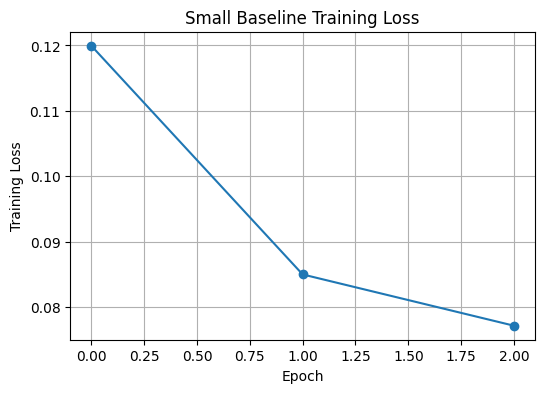

In [15]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Small Baseline Training Loss")
plt.grid(True)
plt.show()

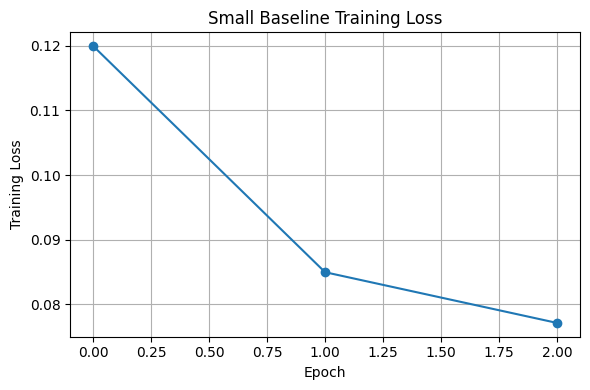

In [16]:
os.makedirs("results/figures/training", exist_ok=True)

plt.figure(figsize=(6, 4))
plt.plot(train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Small Baseline Training Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig("results/figures/training/small_baseline_loss.png", dpi=200)
plt.show()

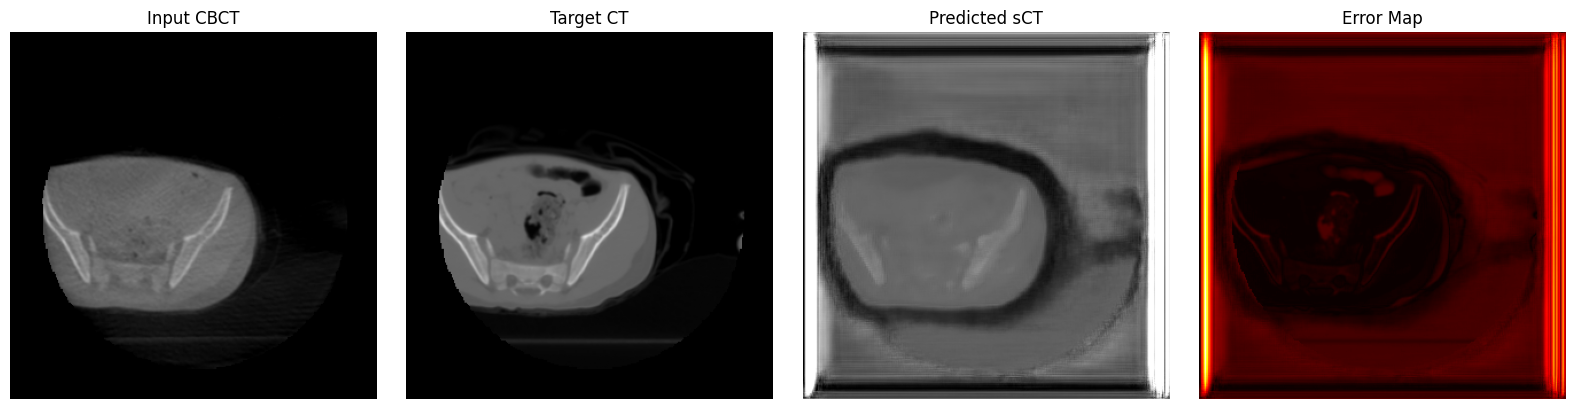

In [17]:
model.eval()

batch = next(iter(val_loader))

inputs = batch["input"].to(device)
targets = batch["target"].to(device)
masks = batch["mask"].to(device)

with torch.no_grad():
    outputs = model(inputs)

input_np = inputs[0].cpu().numpy()
target_np = targets[0, 0].cpu().numpy()
output_np = outputs[0, 0].cpu().numpy()
mask_np = masks[0, 0].cpu().numpy()

center_slice = input_np.shape[0] // 2

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(input_np[center_slice], cmap="gray", vmin=-1, vmax=1)
plt.title("Input CBCT")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(target_np, cmap="gray", vmin=-1, vmax=1)
plt.title("Target CT")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(output_np, cmap="gray", vmin=-1, vmax=1)
plt.title("Predicted sCT")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(abs(output_np - target_np), cmap="hot")
plt.title("Error Map")
plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
os.makedirs("checkpoints/small_baseline", exist_ok=True)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses
    },
    "checkpoints/small_baseline/model_3epochs.pth"
)

print("Saved small baseline checkpoint.")

Saved small baseline checkpoint.
